# **Import Lib**

In [ ]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data

import random
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader


In [ ]:
# Set seed
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

In [ ]:
!gdown 1VV0PMjyXqtF--fmiJJWPXI0jaQRxqtqe

Downloading...
From (original): https://drive.google.com/uc?id=1VV0PMjyXqtF--fmiJJWPXI0jaQRxqtqe
From (redirected): https://drive.google.com/uc?id=1VV0PMjyXqtF--fmiJJWPXI0jaQRxqtqe&confirm=t&uuid=05981828-8a6e-4996-98b5-bf1642dcf339
To: /content/violence-not_violence.zip
100% 694M/694M [00:10<00:00, 65.5MB/s]


In [ ]:
!unzip -q /content/violence-not_violence.zip

In [ ]:
img_path = "/content/violence_dataset"

In [ ]:
from imutils import paths

def plot_images(data_dir, label, num_sample=6):
    data_dir = os.path.join(data_dir, label)
    image_files = list(paths.list_images(data_dir))[:num_sample]
    fig, ax = plt.subplots(2,num_sample//2, figsize=(14,7))
    for i, image_dir in enumerate(image_files):
        img = Image.open(image_dir)
        label = image_dir.split('/')[-2]
        ax[i//(num_sample//2)][i%(num_sample//2)].imshow(img)
        ax[i//(num_sample//2)][i%(num_sample//2)].set_title(label)
        ax[i//(num_sample//2)][i%(num_sample//2)].axis('off')
    plt.tight_layout()
    plt.show()

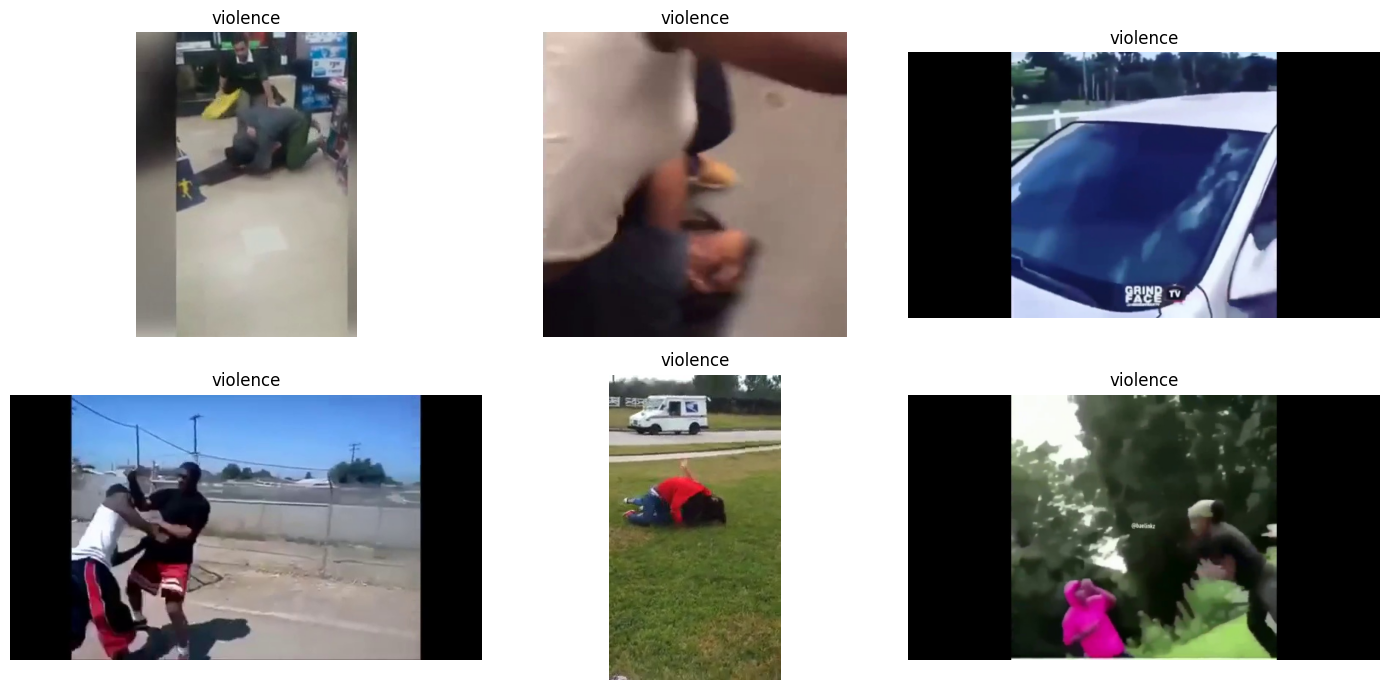

In [ ]:
plot_images(img_path, "violence")

# **Chia dữ liệu thành tập train và test**

In [ ]:
import shutil
from sklearn.model_selection import train_test_split
from imutils import paths # Assuming imutils.paths is available from previous imports

# Define the base directory for the dataset
base_dataset_dir = img_path # This variable is defined in cell ST6Sh-R8ZiEG

# Define the base directories for train and test splits
# Using the train_dir and test_dir variables from cell zI-tmUEHvnee, prefixed with /content
train_base_dir = "/content/train"
test_base_dir = "/content/test"

# Get all image paths
image_paths = list(paths.list_images(base_dataset_dir))

# Extract labels from paths (assuming directory structure like dataset_root/label/image.jpg)
# e.g., /content/violence_dataset/violence/img1.jpg -> 'violence'
labels = [p.split(os.path.sep)[-2] for p in image_paths]

# Perform train-test split
# Using stratify to maintain the proportion of classes in both train and test sets
train_paths, test_paths, train_labels, test_labels = train_test_split(
    image_paths, labels, test_size=0.2, random_state=42, stratify=labels
)

print(f"Total images: {len(image_paths)}")
print(f"Training images: {len(train_paths)}")
print(f"Testing images: {len(test_paths)}")

# Function to create directories and copy files
def create_split_directory(image_list, base_output_dir):
    # Ensure the base output directory exists
    if not os.path.exists(base_output_dir):
        os.makedirs(base_output_dir)

    for image_path in image_list:
        # Extract the label (class name) from the image path
        label = image_path.split(os.path.sep)[-2]
        # Extract the filename
        filename = os.path.basename(image_path)

        # Create the class subdirectory within the base output directory (e.g., /content/train/violence)
        class_output_dir = os.path.join(base_output_dir, label)
        if not os.path.exists(class_output_dir):
            os.makedirs(class_output_dir)

        # Define the destination path for the image
        destination_path = os.path.join(class_output_dir, filename)

        # Copy the image
        shutil.copyfile(image_path, destination_path)


print("\nCreating training directory and copying images...")
create_split_directory(train_paths, train_base_dir)
print(f"Training data created in: {train_base_dir}")

print("\nCreating testing directory and copying images...")
create_split_directory(test_paths, test_base_dir)
print(f"Testing data created in: {test_base_dir}")

Total images: 11063
Training images: 8850
Testing images: 2213

Creating training directory and copying images...
Training data created in: /content/train

Creating testing directory and copying images...
Testing data created in: /content/test


In [ ]:
train_dir = "/content/train"
test_dir = "/content/test"

# **Check imbalance data**

In [ ]:
import pandas as pd
from pathlib import Path

data = train_dir

all_image_data = []
for class_dir in Path(data).iterdir(): # Iterate through class directories
    if class_dir.is_dir(): # Ensure it's a directory
        class_name = class_dir.name
        for img_path in class_dir.rglob('*.*'): # Iterate through images in class directory
            if img_path.is_file(): # Ensure it's a file
                # The 'Images' column should be 'ClassDir/image_filename' for flow_from_dataframe
                relative_image_path = Path(class_name) / img_path.name
                all_image_data.append({'Class': class_name, 'Images': str(relative_image_path)})

df = pd.DataFrame(all_image_data)
df = df.sort_values('Class', ascending=True)
df.reset_index(drop=True, inplace=True)
df

,Class,Images
0,non_violence,non_violence/NV_736.mp4_frame5.jpg
1,non_violence,non_violence/NV_301.mp4_frame4.jpg
2,non_violence,non_violence/NV_197.mp4_frame3.jpg
3,non_violence,non_violence/NV_286.mp4_frame2.jpg
4,non_violence,non_violence/NV_342.mp4_frame4.jpg
...,...,...
8845,violence,violence/V_776.mp4_frame3.jpg
8846,violence,violence/V_352.mp4_frame5.jpg
8847,violence,violence/V_968.mp4_frame5.jpg
8848,violence,violence/V_789.mp4_frame305.jpg


In [ ]:
print('Count the number of image datasets')
print(f"Image Count : {len(df["Images"])}")
print(f"Class Count : {len(df['Class'].value_counts())} \n")
print('Count the number of images in each class')
print(df['Class'].value_counts())

Count the number of image datasets
Image Count : 8850
Class Count : 2 

Count the number of images in each class
Class
violence        4665
non_violence    4185
Name: count, dtype: int64


Text(0, 0.5, 'Count Image')

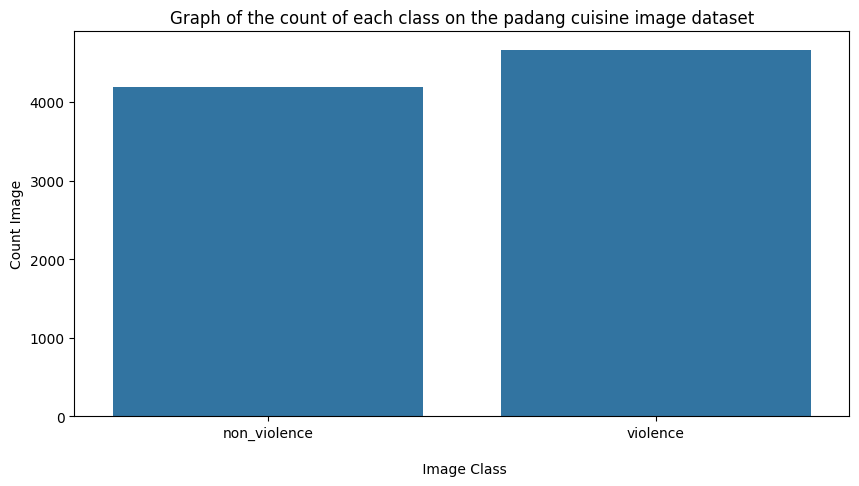

In [ ]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(10,5))
sns.countplot(data=df, x='Class')
plt.title('Graph of the count of each class on the padang cuisine image dataset')
plt.xlabel('\n Image Class')
plt.ylabel('Count Image')

# **Check size images**

In [ ]:
import random
from PIL import Image
import os

# Get a list of all image paths in the train_dir
image_paths = []
for class_dir in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_dir)
    if os.path.isdir(class_path):
        for image_name in os.listdir(class_path):
            if image_name.endswith(('.jpg', '.jpeg', '.png', '.gif')):
                image_paths.append(os.path.join(class_path, image_name))

# Randomly select 10 image paths
num_samples = 10
if len(image_paths) < num_samples:
    print(f"Warning: Only {len(image_paths)} images found. Checking all of them.")
    random_image_paths = image_paths
else:
    random_image_paths = random.sample(image_paths, num_samples)

print(f"Checking size of {len(random_image_paths)} random images from {train_dir}:")
for i, img_path in enumerate(random_image_paths):
    try:
        with Image.open(img_path) as img:
            print(f"Image {i+1}: {os.path.basename(img_path)} - Size: {img.size} (Width, Height)")
    except Exception as e:
        print(f"Error opening image {img_path}: {e}")


Checking size of 10 random images from /content/train:
Image 1: V_78.mp4_frame0.jpg - Size: (640, 360) (Width, Height)
Image 2: V_789.mp4_frame302.jpg - Size: (1280, 720) (Width, Height)
Image 3: V_967.mp4_frame2.jpg - Size: (406, 720) (Width, Height)
Image 4: V_906.mp4_frame4.jpg - Size: (360, 360) (Width, Height)
Image 5: V_865.mp4_frame4.jpg - Size: (726, 670) (Width, Height)
Image 6: V_695.mp4_frame3.jpg - Size: (224, 224) (Width, Height)
Image 7: V_621.mp4_frame0.jpg - Size: (224, 224) (Width, Height)
Image 8: V_338.mp4_frame3.jpg - Size: (640, 360) (Width, Height)
Image 9: NV_929.mp4_frame4.jpg - Size: (224, 224) (Width, Height)
Image 10: V_41.mp4_frame2.jpg - Size: (1280, 720) (Width, Height)


=> Resize to 224x224

In [ ]:
img_size = 224
batch_size = 32

# **Compute mean and std of dataset**

In [ ]:
# Compute the mean and std of dataset
# Define a transform to resize and convert images to tensors (without normalization yet)
# Assuming images will be resized to 224x224 based on previous context.
transform_for_mean_std = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor()
])

# Create a dataset
train_dataset_mean_std = ImageFolder(root=train_dir, transform=transform_for_mean_std)

# Create a DataLoader
data_loader_mean_std = DataLoader(train_dataset_mean_std, batch_size=64, shuffle=False, num_workers=2)

print("Calculating mean and standard deviation of the training dataset...")

# Variables to accumulate mean and std
mean = 0.
std = 0.
nb_samples = 0

for data, _ in data_loader_mean_std:
    batch_samples = data.size(0) # batch size (the last batch can have smaller size)
    data = data.view(batch_samples, data.size(1), -1)
    mean += data.mean(2).sum(0)
    std += data.std(2).sum(0)
    nb_samples += batch_samples

mean /= nb_samples
std /= nb_samples

dataset_mean = mean.numpy()
dataset_std = std.numpy()

print(f"Calculated Mean of training dataset: {dataset_mean}")
print(f"Calculated Std Dev of training dataset: {dataset_std}")


Calculating mean and standard deviation of the training dataset...
Calculated Mean of training dataset: [0.4002993  0.37603003 0.3600476 ]
Calculated Std Dev of training dataset: [0.22226045 0.21355577 0.21133435]


# **Create train-test transform**

In [ ]:
train_transforms = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomRotation(degrees=(90, 90)),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=dataset_mean, std=dataset_std)
])

test_transforms = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=dataset_mean, std=dataset_std)
])

# **Create Dataset**

In [ ]:
train_dataset = datasets.ImageFolder(
    root=train_dir,
    transform=train_transforms

)

test_dataset = datasets.ImageFolder(
    root=test_dir,
    transform=test_transforms
)

# **Create DataLoader**

In [ ]:
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=False
)

# **Load pretrained model**

In [ ]:
from torchvision import models
# Load DenseNet
weights = models.DenseNet201_Weights.IMAGENET1K_V1 # Corrected to use specific DenseNet201 weights
model = models.densenet201(weights=weights) # Removed redundant 'pretrained=False' when specifying weights

# **Training (Fine Tunning)**

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
for param in model.parameters():
    param.requires_grad = True

in_features = model.classifier.in_features
model.classifier = nn.Linear(in_features=in_features, out_features=2)

model.to(device)

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

In [ ]:
def train(model, train_loader, criterion, optimizer, device):
    model.train()
    losses = []
    accs = []
    for idx, (images, labels) in enumerate(train_loader):
        # 1. Load image and label to device
        images, labels = images.to(device), labels.to(device)

        # 2. Forward
        preds = model(images)

        # 3. Compute loss
        loss = criterion(preds, labels)
        losses.append(loss.item())

        correct = torch.argmax(preds, dim=1)
        acc = (correct == labels).sum().item()
        accs.append(acc / len(labels))

        # 4. Clear gradients
        optimizer.zero_grad()

        # 5. Backward
        loss.backward()

        # 6. Update gradients
        optimizer.step()

    return sum(losses) / len(train_loader), sum(accs) / len(train_loader)

In [ ]:
def evaluate(model, test_loader, criterion, device):
    model.eval()
    losses = []
    accs = []
    with torch.inference_mode():
        for idx, (images, labels) in enumerate(test_loader):
            images, labels = images.to(device), labels.to(device)

            preds = model(images)

            loss = criterion(preds, labels)
            losses.append(loss.item())

            correct = torch.argmax(preds, dim=1)
            acc = (correct == labels).sum().item()
            accs.append(acc / len(labels))


    loss, acc = sum(losses) / len(test_loader), sum(accs) / len(test_loader)
    return loss, acc

In [ ]:
def trainning_loop(model, train_loader, val_loader, criterion, optimizer, epochs, device):
    train_losses = []
    train_accs = []
    val_losses = []
    val_accs = []
    best_val_loss = float('inf')
    for epoch in range(epochs):
        train_loss, train_acc = train(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        print(f"Epoch: {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            checkpoint = {
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': best_val_loss,
            }
            torch.save(checkpoint, "/content/drive/MyDrive/CyberSoft_Courses/ML_DL_04/final_capstone/models/best_densenet_model.pth")
            print(f"Saved best model at epoch {epoch + 1}!")
    return train_losses, train_accs, val_losses, val_accs


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=2e-6)
epochs = 10

In [ ]:
train_losses, train_accs, val_losses, val_accs = trainning_loop(
    model=model,
    train_loader=train_loader,
    val_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    epochs=epochs,
    device=device
)

Epoch: 1/10 | Train Loss: 0.5376 | Train Acc: 0.7473 | Val Loss: 0.4704 | Val Acc: 0.8326
Saved best model at epoch 1!
Epoch: 2/10 | Train Loss: 0.3299 | Train Acc: 0.9013 | Val Loss: 0.3629 | Val Acc: 0.8853
Saved best model at epoch 2!
Epoch: 3/10 | Train Loss: 0.2422 | Train Acc: 0.9253 | Val Loss: 0.3080 | Val Acc: 0.8929
Saved best model at epoch 3!
Epoch: 4/10 | Train Loss: 0.1970 | Train Acc: 0.9355 | Val Loss: 0.2741 | Val Acc: 0.8982
Saved best model at epoch 4!
Epoch: 5/10 | Train Loss: 0.1601 | Train Acc: 0.9509 | Val Loss: 0.2492 | Val Acc: 0.9085
Saved best model at epoch 5!
Epoch: 6/10 | Train Loss: 0.1386 | Train Acc: 0.9554 | Val Loss: 0.2466 | Val Acc: 0.9049
Saved best model at epoch 6!
Epoch: 7/10 | Train Loss: 0.1170 | Train Acc: 0.9650 | Val Loss: 0.2352 | Val Acc: 0.9080
Saved best model at epoch 7!
Epoch: 8/10 | Train Loss: 0.0975 | Train Acc: 0.9706 | Val Loss: 0.2151 | Val Acc: 0.9147
Saved best model at epoch 8!
Epoch: 9/10 | Train Loss: 0.0850 | Train Acc: 0.

# **Visualize loss plot**

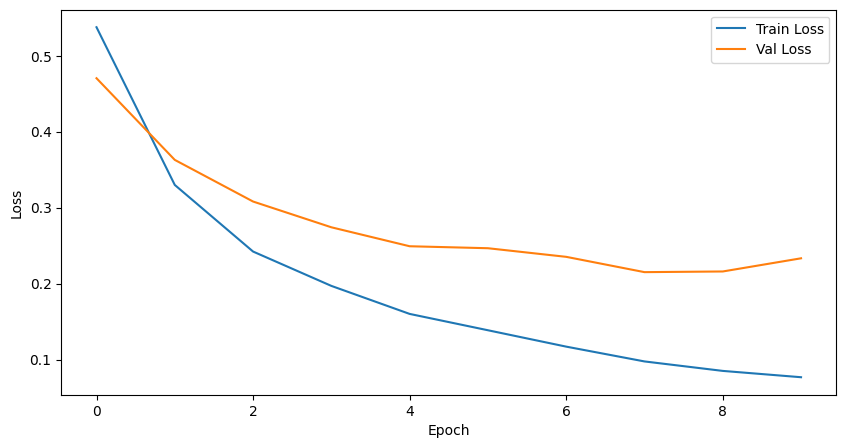

In [ ]:
# Loss Plot
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()